# Prototype clear sar
Clear and filter sentinel data

In [2]:
import pandas as pd
import os 
import pyarrow.parquet as pq

# Set

In [5]:
year = 2025
raw_path = 'data/raw/from_notebooks'
ds_name = f"s2_vessel_detections_{str(year)}.parquet"

inp = os.path.join(raw_path, ds_name)

out_path = 'data/interim/from_notebooks'
out_name = f'cleaned_{ds_name}'
out = os.path.join(out_path, out_name)

# Import 

In [6]:
# pq.read_table -> get parquet data with the proper lib
# use_pandas_metadata=False -> ignore the pandas metadata
table = pq.read_table(inp, use_pandas_metadata=False)  
# to_pandas -> convert to pandas dataframe
# ignore_metadata=True -> ignore the pandas metadata
df = table.to_pandas(ignore_metadata=True)  

# Clean
Drop, rename, sort columns.

In [7]:
cols_to_drop = [
    'detect_timestamp', 
] 

df = df.drop(columns=cols_to_drop)

In [8]:
rename_dict = {
    'detect_lat': 'latitude',
    'detect_lon': 'longitude',
}

df = df.rename(columns=rename_dict)

In [9]:
cols_ordered = [
    'date', 'latitude', 'longitude', 'ssvid', 'speed_kn_inferred', 'heading_deg_inferred', 'length_m_inferred','presence_score', 'matching_score', 'cloud_score', 'likely_infrastructure'
]

df = df[cols_ordered]

In [10]:
df.head()

,date,latitude,longitude,ssvid,speed_kn_inferred,heading_deg_inferred,length_m_inferred,presence_score,matching_score,cloud_score,likely_infrastructure
0,2025-11-10,45.685675,13.602083,None,1.66,226.982539,23.3,0.908,0.0,0.000086,False
1,2025-11-10,45.793961,13.544950,None,2.00,322.093533,203.4,0.374,0.0,0.080936,False
2,2025-11-10,45.654915,13.233456,None,4.49,295.164517,23.5,0.939,0.0,0.000087,False
3,2025-11-10,45.625550,13.352400,None,3.33,298.602264,30.1,0.938,0.0,0.000099,False
4,2025-11-10,45.758898,13.591254,None,1.69,59.587611,28.5,0.742,0.0,0.000094,False


# Filter fishing vessels

I chose the following filter:
- speed_kn_inferred: [0,9] (vessel ship at most in [2,8], and some at [0,8])
- lengh_m_inferred: <25 (usually at a maximum length of 18 m)
- presence_score: > 0.5
- cloud score: < 0.5 
- likely_infrascture: False 

In [11]:
n_total = len(df)

# Filters
spd_mask = df['speed_kn_inferred'] < 9
len_mask = df['length_m_inferred'] < 25
prs_mask = df['presence_score'] > 0.5
cld_mask = df['cloud_score'] < 0.5
inf_mask = df['likely_infrastructure'] == False

# Show how many elements are removed for each filter 
masks = {
    "speed < 9": spd_mask,
    "length < 25": len_mask,
    "presence > 0.5": prs_mask,
    "cloud < 0.5": cld_mask,
    "not infrastructure": inf_mask,
}

for name, mask in masks.items():
    n_pass = mask.sum()
    n_removed = n_total - n_pass
    perc_removed = 100 * n_removed / n_total
    print(f"{name:25s} removed {n_removed:8d} rows ({perc_removed:6.2f}%)")

# Perform the filter 
full_mask = spd_mask & len_mask & prs_mask & cld_mask & inf_mask
n_after = full_mask.sum()
print("\nCombined filters:")
print(f"  Records before filtering: {n_total}")
print(f"  Records after filtering:  {n_after}")
print(f"  Records removed:          {n_total - n_after} ({100*(n_total-n_after)/n_total:.2f}%)")

df = df.loc[full_mask].copy()


speed < 9                 removed     1561 rows (  7.57%)
length < 25               removed    12117 rows ( 58.74%)
presence > 0.5            removed     1748 rows (  8.47%)
cloud < 0.5               removed     2169 rows ( 10.52%)
not infrastructure        removed       11 rows (  0.05%)

Combined filters:
  Records before filtering: 20627
  Records after filtering:  6565
  Records removed:          14062 (68.17%)


# Clean no more useful columns 

In [12]:
cols_to_drop = [
    'matching_score',
    'cloud_score',
    'likely_infrastructure',
]

df = df.drop(columns=cols_to_drop)

# Filter only the italian region 

In [13]:
import matplotlib.pyplot as plt
bounds_df = pd.read_csv('data/raw/italy_marine_bounds.csv')
gulf_df = pd.read_csv('data/raw/ts_gulf_coords.csv')

In [14]:
unq_coords = df.drop_duplicates(subset=['latitude', 'longitude']).copy()

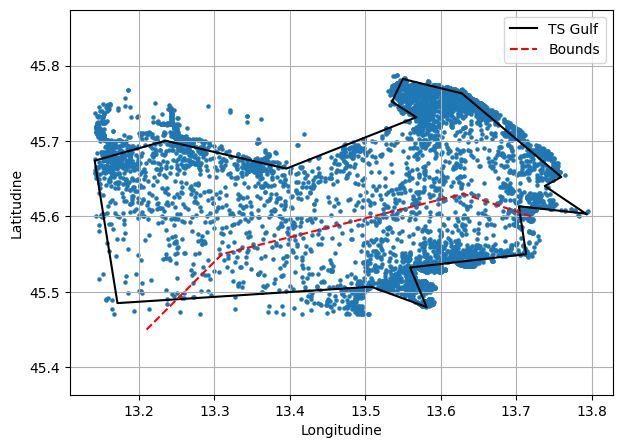

In [15]:
plt.figure(figsize=(7,5))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.plot(bounds_df['longitude'], bounds_df['latitude'], label = 'Bounds', color = 'red', linestyle='--')
plt.scatter(unq_coords['longitude'], unq_coords['latitude'], s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

In [16]:
import geopandas as gpd
from shapely.geometry import LineString, Point

def filter_above_boundary(df, bounds_df):
    # --- Boundary ---
    boundary_line = LineString(zip(bounds_df.longitude, bounds_df.latitude))

    # --- Ship points ---
    gdf = gpd.GeoDataFrame(
        df,
        geometry=[Point(xy) for xy in zip(df.longitude, df.latitude)]
    )

    def is_above_line(point, line):
        projection = line.interpolate(line.project(point))
        return point.y > projection.y

    gdf["above"] = gdf.geometry.apply(lambda p: is_above_line(p, boundary_line))

    filtered = gdf[gdf["above"]]
    
    return filtered.drop(columns=['geometry', 'above'])


In [17]:
filtered = filter_above_boundary(df, bounds_df)

In [18]:
fil_unq_coords = filtered.drop_duplicates(subset=['latitude', 'longitude']).copy()

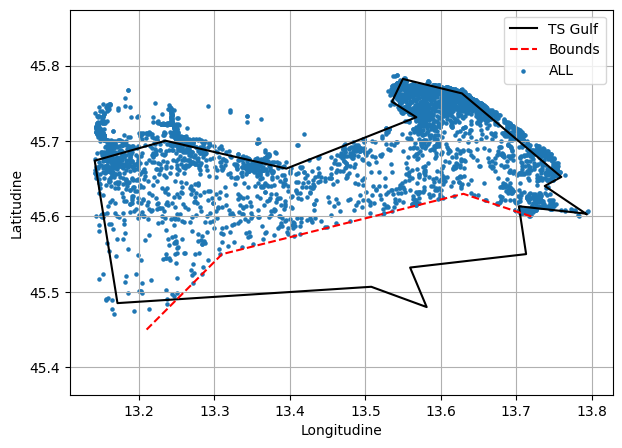

In [19]:
plt.figure(figsize=(7,5))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.plot(bounds_df['longitude'], bounds_df['latitude'], label = 'Bounds', color = 'red', linestyle='--')
plt.scatter(fil_unq_coords['longitude'], fil_unq_coords['latitude'], label = 'ALL', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

# Export 

In [20]:
filtered.to_parquet(out, index=False)